In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\1_chain\2_comp
scenario=2comp_equal  K_MODEL=5  K_TRUE=2
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (1, 10000, 5, 4)
  HMC      mu (1, 10000, 5, 4)
  NUTS     mu (1, 10000, 5, 4)
  replication mu (1, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids ──────────
# Grids are anchored to the FITTED models' live-component support (union over
# samplers); the True DGP is an overlay only, never used to set the bounds.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

grids = mc.build_grids(models, K_true=K_TRUE, n_grid=1000, n_sigma=4)
print("Grid extents (fitted-support, live components):")
for j, pj in enumerate(param_names):
    print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents (fitted-support, live components):
  Alt1       [-4.55, +11.10]
  Alt2       [-8.11, +12.11]
  Alt3       [-4.28, +9.48]
  Price      [-14.99, +2.63]


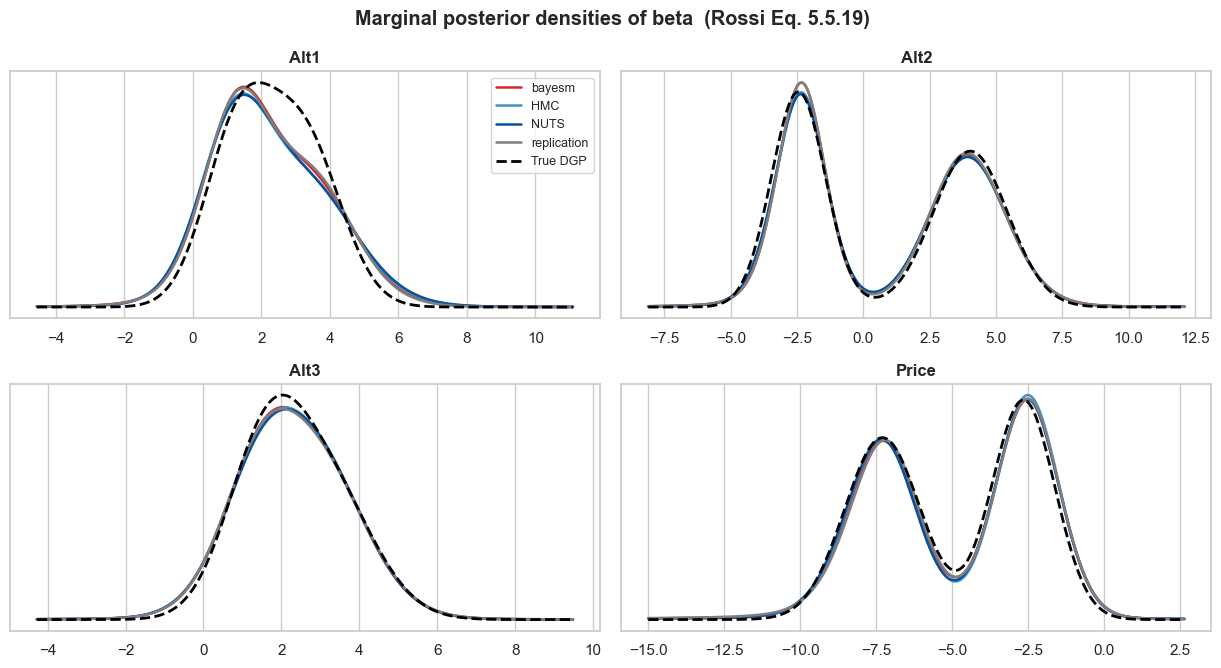

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) ──────────
dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
dens_true = mc.marginal_density(true_model, grids)
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light).
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "iwls": "#9ecae1", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"

ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
ax = axes.ravel()
for j, pj in enumerate(param_names):
    for name, d in dens.items():
        ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
    ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
    ax[j].set_title(pj, fontweight="bold")
    ax[j].set_yticks([])
for j in range(P, len(ax)):
    ax[j].set_visible(False)
ax[0].legend(fontsize=9)
fig.suptitle("Marginal posterior densities of beta  (Rossi Eq. 5.5.19)", fontweight="bold")
fig.tight_layout()
plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP ──────────
# Every sampler's marginal is compared ONLY to the True DGP marginal (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1. All label-invariant - relabeling/ECR would not
# change them.
display(mc.distance_table(models, true_model, grids, param_names))

Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.10475  0.06547  0.01027  0.09371       0.24238
            Alt2     0.06032  0.02543  0.00328  0.04170       0.12132
            Alt3     0.04805  0.01563  0.00210  0.02432       0.06679
            Price    0.06234  0.03330  0.00343  0.04325       0.15879
HMC         Alt1     0.11880  0.08701  0.01318  0.10709       0.27877
            Alt2     0.05644  0.02240  0.00287  0.03948       0.11670
            Alt3     0.05072  0.01840  0.00232  0.02491       0.06410
            Price    0.07095  0.04789  0.00434  0.04753       0.16891
NUTS        Alt1     0.12029  0.09035  0.01347  0.10594       0.27601
            Alt2     0.05321  0.02005  0.00256  0.03620       0.11303
            Alt3     0.05208  0.01898  0.00245  0.02746       0.06460
            Price    0.06741  0.04080  0.00395  0.04240       0.15817
replication Alt1     0.10033  0.05959  0.00946  0.09151       0.23316
            Alt2     0.05638  0.02148  0.00289  0.04064       0.11650
            Alt3     0.04886  0.01610  0.00217  0.02602       0.07062
            Price    0.07359  0.04906  0.00468  0.04739       0.17659

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.209,2.181,2.170,2.203,2.307
Alt2,0.875,0.927,0.960,0.892,0.791
Alt3,2.292,2.268,2.267,2.283,2.357
Price,-4.973,-4.935,-4.951,-4.990,-4.978


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,3.093,7.837,8.924000,3.094,1.982
Alt2,12.361,15.337,17.589001,12.701,12.009
Alt3,2.361,3.847,4.076000,2.886,1.840
Price,9.704,9.397,9.463000,11.083,6.678


In [7]:
# ── Cell 7 : Invariant Convergence - Marginal Density Series ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the label-invariant per-draw
# marginal density, over the high-density region of each parameter.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40).round(3))

NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a
      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).
      It cannot detect multimodality a lone chain never explored - the
      between-chain R-hat comes from the 2-chain runs.

--- bayesm ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,25,54.707,216.519,1.034,1.014
Alt2,29,21.211,434.987,1.074,1.008
Alt3,25,156.031,558.515,1.009,1.004
Price,29,73.391,835.421,1.049,1.013


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,25,10.836,53.708,1.128,1.040
Alt2,29,5.921,89.226,1.249,1.042
Alt3,25,35.313,114.686,1.051,1.013
Price,29,7.435,174.230,1.217,1.028


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,25,166.869,513.416,1.024,1.008
Alt2,28,69.270,792.048,1.033,1.005
Alt3,25,311.077,759.324,1.012,1.003
Price,29,44.686,1207.006,1.044,1.008


--- replication ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,25,119.763,245.115,1.021,1.011
Alt2,29,14.922,395.699,1.103,1.014
Alt3,25,164.593,433.744,1.018,1.006
Price,31,49.397,585.231,1.042,1.014


In [8]:
# ── Cell 8 : Invariant Convergence - Moment Series & Notes ──────────
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is")
print("   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,")
print("   so relabeling/ECR is unnecessary and would give identical results.")
print(" - The grid is anchored to the fitted models' live-component support; the True")
print("   DGP is an overlay only, never used to set the bounds.")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC (per CLAUDE.md).")

--- bayesm ---


ESS    Rhat
param moment                  
Alt1  Mean    290.2729  1.0166
      Var     505.9402  1.0063
Alt2  Mean    496.1786  1.0064
      Var     145.2468  1.0182
Alt3  Mean    642.7892  1.0033
      Var     898.5981  1.0014
Price Mean     30.2314  1.0473
      Var      12.1916  1.1231

--- HMC ---


ESS    Rhat
param moment                  
Alt1  Mean     95.9350  1.0200
      Var      52.1053  1.0394
Alt2  Mean     51.3963  1.0181
      Var      48.2056  1.0519
Alt3  Mean    101.8333  1.0092
      Var      96.8397  1.0080
Price Mean     18.4450  1.0780
      Var       7.7766  1.1915

--- NUTS ---


ESS    Rhat
param moment                  
Alt1  Mean    375.1328  1.0046
      Var     325.7585  1.0090
Alt2  Mean    360.1675  1.0129
      Var     197.3972  1.0095
Alt3  Mean    374.5280  1.0019
      Var     304.8499  1.0061
Price Mean     93.4955  1.0215
      Var      44.3305  1.0478

--- replication ---


ESS    Rhat
param moment                  
Alt1  Mean    478.2941  1.0016
      Var     193.9647  1.0118
Alt2  Mean    741.2153  1.0026
      Var      18.1295  1.0866
Alt3  Mean    107.1782  1.0117
      Var     113.9433  1.0218
Price Mean      8.2388  1.1679
      Var       4.6876  1.3466


Notes:
 - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is
   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,
   so relabeling/ECR is unnecessary and would give identical results.
 - The grid is anchored to the fitted models' live-component support; the True
   DGP is an overlay only, never used to set the bounds.
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   than NUTS/HMC (per CLAUDE.md).
